# Estadística para IA

**Lo que sale de aquí:**
- Saber muestrear de una distribución sin llamar una función mágica de una sola línea: vamos a construir el mecanismo generador nosotros mismos
- Ver con los propios ojos que histograma se parece a pdf, que la CDF empírica se pega a la teórica, y que la media muestral converge
- Entender de qué *proceso* surge cada familia común (Bernoulli/Binomial, Poisson, Exponencial/Gamma, Normal, Beta) no solo memorizar sus nombres

**Antes de empezar:** en Colab, corre cada celda en orden (Shift+Enter). Si una celda tiene `# TODO`, complétala antes de correrla.


## Setup y reconexión con lo visto en clase

Recordatorio rápido de S1:

- $F(x) = P(X \leq x)$ describe *toda* la incertidumbre sobre $X$
- $p(x) = P(X=x)$ es la lectura discreta de $F$; $f(x) = F'(x)$ es la lectura continua
- La densidad **no** es una probabilidad; el área bajo $f$ sí lo es

Hoy vamos a ver estos objetos generados por código, no solo dibujados en una lámina.

**Entorno:** trabajamos en Google Colab. NumPy, SciPy, pandas y Matplotlib ya vienen preinstalado, no hace falta instalar nada para el contenido de hoy.

Vamos a necesitar PyMC y ArviZ más adelante, cuando lleguemos a la parte de Núcleo Bayesiano. La celda de abajo queda comentada como referencia; no hace falta correrla hoy.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Semilla fija: así todos obtenemos los mismos números en clase.
# Quitar o cambiar la semilla da resultados distintos (pero estadísticamente equivalentes).
np.random.seed(9091989)

# Paleta para que las gráficas de hoy combinen con las láminas de S1
TEAL = "#169685"
SLATE = "#283747"

# Referencia para más adelante (parte de Núcleo Bayesiano). No hace falta correr hoy:
# !pip install pymc arviz --quiet


## Transformada inversa: construir la Exponencial desde una Uniforme

Vamos a explorar una idea muy sencilla para simular (generar) números que vengan de una distribución exponencial

Idea central: si $U \sim \text{Uniforme}(0,1)$ y $F$ es la CDF que quiero simular, entonces
$$X = F^{-1}(U)$$
tiene exactamente la distribución $F$. Esto es literalmente invertir el objeto que ya conocemos de S1.

Para la Exponencial($\lambda$): $F(x) = 1-e^{-\lambda x}$. Despejando $x$ de $u = 1-e^{-\lambda x}$:
$$F^{-1}(u) = -\frac{\ln(1-u)}{\lambda}$$

Vamos a usar $\lambda=1.3$


In [5]:
def simular_exponencial(lam, n):
    """Genera n muestras de una Exponencial(lam) invirtiendo su CDF."""
    U = np.random.rand(n)
    X = -np.log(U) / lam
    return X

lam = 1.3
n = 20000
muestras_exp = simular_exponencial(lam, n)

print(f"media muestral: {muestras_exp.mean():.4f}   media teórica (1/lambda): {1/lam:.4f}")

media muestral: 0.7717   media teórica (1/lambda): 0.7692


**Chequeo:** las dos medias de arriba deberían quedar cerca una de la otra (no idénticas, estamos simulando). Si están muy lejos, algo está mal en la fórmula de arriba.

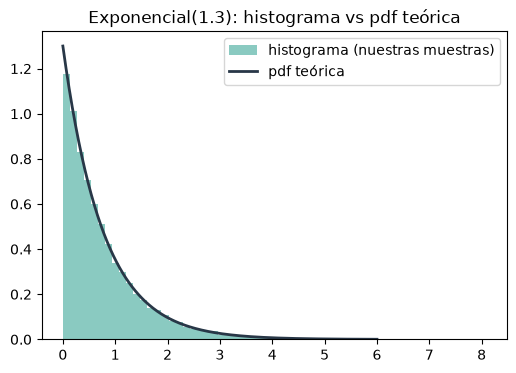

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(muestras_exp, bins=60, density=True, color=TEAL, alpha=0.5, label="histograma (nuestras muestras)")
xs = np.linspace(0, 6, 300)
ax.plot(xs, stats.expon(scale=1/lam).pdf(xs), color=SLATE, lw=2, label="pdf teórica")
ax.set_title("Exponencial(1.3): histograma vs pdf teórica")
ax.legend()
plt.show()


Ahora la CDF: construimos la **CDF empírica** directamente de las muestras: para cada $x$, qué fracción de mis muestras cayó en $X \leq x$, y la comparamos con la teórica.

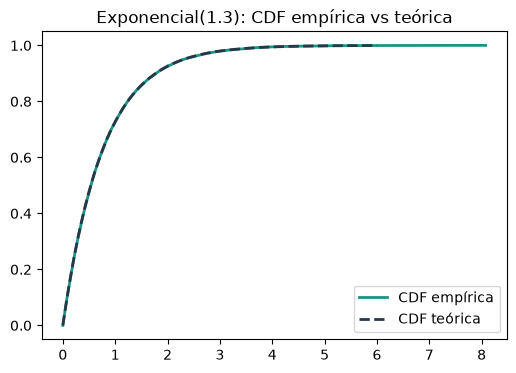

In [7]:
xs_ordenadas = np.sort(muestras_exp)
cdf_empirica = np.arange(1, n+1) / n

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(xs_ordenadas, cdf_empirica, color=TEAL, lw=2, label="CDF empírica")
xs = np.linspace(0, 6, 300)
ax.plot(xs, stats.expon(scale=1/lam).cdf(xs), color=SLATE, lw=2, ls="--", label="CDF teórica")
ax.set_title("Exponencial(1.3): CDF empírica vs teórica")
ax.legend()
plt.show()


## Ley de los Grandes Números, con la Exponencial que ya construimos

Hoy la vemos de manera empírica la LGN: conforme $n$ crece, la media de las primeras $n$ muestras debería acercarse a la media teórica $1/\lambda$.


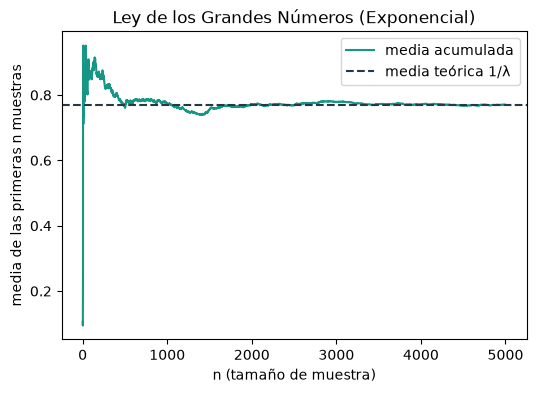

In [8]:
ns = np.arange(1, 5001)
medias_acumuladas = np.cumsum(muestras_exp[:5000]) / ns

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(ns, medias_acumuladas, color=TEAL, lw=1.5, label="media acumulada")
ax.axhline(1/lam, color=SLATE, ls="--", label="media teórica 1/λ")
ax.set_xlabel("n (tamaño de muestra)")
ax.set_ylabel("media de las primeras n muestras")
ax.set_title("Ley de los Grandes Números (Exponencial)")
ax.legend()
plt.show()


## Bernoulli, y de ahí Binomial

Historia generativa: un Bernoulli($p$) es un solo ensayo con probabilidad $p$ de éxito. Un Binomial($n,p$) es, por definición, **la cuenta de éxitos en $n$ ensayos Bernoulli($p$) independientes**. No hay más misterio que ese.

Ejemplo con sabor a S1: de 20 solicitudes a un servidor, cada una falla independientemente con probabilidad $p=0.1$. (Nota: esto es un modelo paramétrico limpio para practicar; la tabla de S1 era solo ilustrativa, no venía de este modelo exacto.)


In [9]:
n_ensayos = 20
p = 0.1
n_muestras = 20000

# Para cada una de las n_muestras réplicas, simulamos n_ensayos Bernoulli(p) y contamos éxitos.
ensayos = np.random.rand(n_ensayos, n_muestras) < p   # matriz booleana (n_ensayos x n_muestras)
exitos = ensayos.sum(axis=0)

print(f"media muestral: {exitos.mean():.4f}   media teórica (n*p): {n_ensayos*p:.4f}")

media muestral: 2.0192   media teórica (n*p): 2.0000


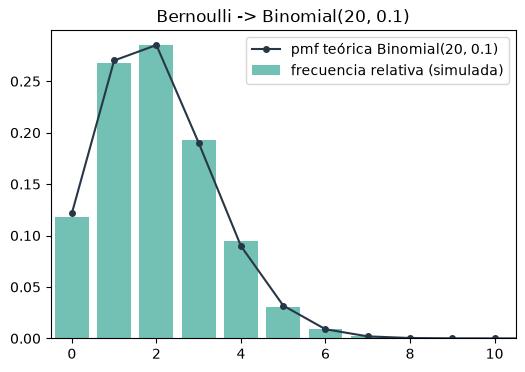

In [10]:
valores, conteos = np.unique(exitos, return_counts=True)
frecuencia_relativa = conteos / n_muestras

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(valores, frecuencia_relativa, color=TEAL, alpha=0.6, label="frecuencia relativa (simulada)")
ks = np.arange(0, n_ensayos+1)
ax.plot(ks, stats.binom(n_ensayos, p).pmf(ks), 'o-', color=SLATE, ms=4, label="pmf teórica Binomial(20, 0.1)")
ax.set_xlim(-0.5, 10.5)
ax.set_title("Bernoulli -> Binomial(20, 0.1)")
ax.legend()
plt.show()


## El proceso de Poisson: de Exponencial a Poisson

Aquí cerramos el círculo con el ancla de S1. Si las solicitudes llegan a un servidor a una tasa constante $\lambda$ por segundo, dos cosas son ciertas a la vez:

- El tiempo **entre** solicitudes consecutivas es Exponencial($\lambda$) -- ya lo construimos en el Bloque 1
- El **número** de solicitudes que llegan en una ventana de tiempo $T$ es Poisson($\lambda T$)

Vamos a construir la segunda a partir de la primera: sumamos tiempos de espera Exponenciales hasta pasarnos de $T$, y contamos cuántas llegadas cupieron antes de $T$.


In [14]:
T = 1.0
n_reps = 20000
max_huecos = 40  # de sobra para lambda=1.3 y T=1: el tiempo esperado para acumular 40 huecos es ~30 segundos

huecos = simular_exponencial(lam, n_reps * max_huecos).reshape(n_reps, max_huecos)
tiempos_llegada = np.cumsum(huecos, axis=1)
conteos_poisson = (tiempos_llegada <= T).sum(axis=1)

# Chequeo de seguridad: si esta probabilidad NO es ~0, max_huecos se quedó corto y hay sesgo.
prob_de_quedarse_corto = (tiempos_llegada[:, -1] <= T).mean()
print(f"prob. de que los {max_huecos} huecos no alcancen para cubrir T: {prob_de_quedarse_corto:.5f}  (debe ser ~0)")
print(f"media muestral: {conteos_poisson.mean():.4f}   media teórica (lambda*T): {lam*T:.4f}")

prob. de que los 40 huecos no alcancen para cubrir T: 0.00000  (debe ser ~0)
media muestral: 1.2987   media teórica (lambda*T): 1.3000


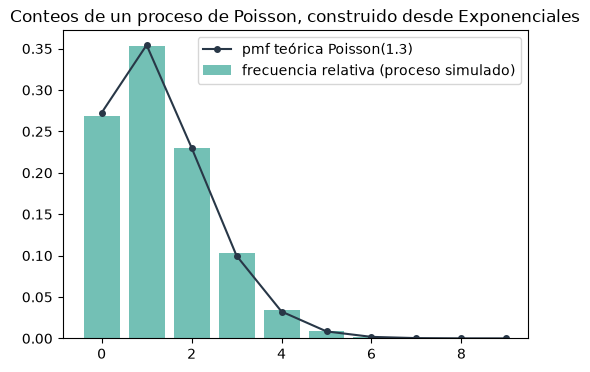

In [12]:
valores_p, conteos_p = np.unique(conteos_poisson, return_counts=True)
frecuencia_relativa_p = conteos_p / n_reps

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(valores_p, frecuencia_relativa_p, color=TEAL, alpha=0.6, label="frecuencia relativa (proceso simulado)")
ks = np.arange(0, valores_p.max()+2)
ax.plot(ks, stats.poisson(lam*T).pmf(ks), 'o-', color=SLATE, ms=4, label=f"pmf teórica Poisson({lam*T})")
ax.set_title("Conteos de un proceso de Poisson, construido desde Exponenciales")
ax.legend()
plt.show()


**Nota al margen (opcional, si hay tiempo):** Poisson también se puede ver como el límite de Binomial($n,p$) cuando $n\to\infty$, $p\to 0$, con $np=\lambda$ fijo, "muchísimos ensayos, cada uno casi imposible". Es la misma familia llegando desde otro camino; no lo vamos a codificar hoy, pero vale la pena que lo tengan en el radar.

## Gamma: el tiempo hasta el $k$-ésimo evento

Si el tiempo entre eventos es Exponencial($\lambda$), el tiempo hasta que ocurra el **tercer** evento es, simplemente, la suma de tres tiempos de espera Exponenciales. Eso es Gamma($k=3, \lambda$), otra vez, construida desde una pieza que ya teníamos.


In [16]:
k = 3
n_muestras_gamma = 20000

# TODO: genera k*n_muestras_gamma exponenciales, acomódalas en (n_muestras_gamma, k) y suma por fila
muestras_gamma =  simular_exponencial(lam, n_muestras_gamma*k).reshape(n_muestras_gamma, k).sum(axis=1)

print(f"media muestral: {muestras_gamma.mean():.4f}   media teórica (k/lambda): {k/lam:.4f}")

media muestral: 2.3271   media teórica (k/lambda): 2.3077


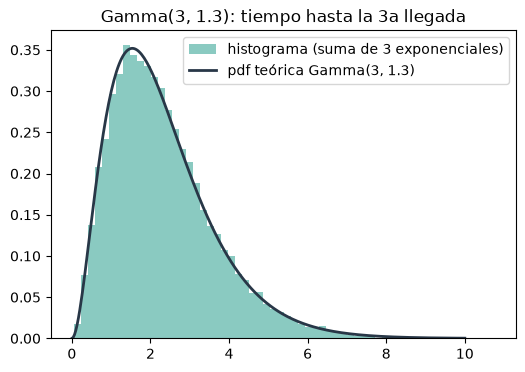

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(muestras_gamma, bins=60, density=True, color=TEAL, alpha=0.5, label="histograma (suma de 3 exponenciales)")
xs = np.linspace(0, 10, 300)
ax.plot(xs, stats.gamma(a=k, scale=1/lam).pdf(xs), color=SLATE, lw=2, label="pdf teórica Gamma(3, 1.3)")
ax.set_title("Gamma(3, 1.3): tiempo hasta la 3a llegada")
ax.legend()
plt.show()


## Normal

**Aviso explícito:** hoy solo *vemos* el fenómeno. El enunciado preciso del Teorema del Límite Central, su verificación cuidadosa y sus condiciones llegan en la Sesión 4, no lo dupliquemos aquí.

Historia generativa a nivel intuitivo: cuando **sumamos** muchas variables aleatorias independientes (casi sin importar de qué distribución vengan) la suma se empieza a ver Normal. Vamos a sumar 30 Uniformes(0,1) y ver qué forma toma.


In [18]:
n_terminos = 30
n_muestras_normal = 20000

sumas = np.random.rand(n_muestras_normal, n_terminos).sum(axis=1)
media_teorica = n_terminos * 0.5
var_teorica = n_terminos * (1/12)

print(f"media muestral: {sumas.mean():.4f}   media teórica: {media_teorica:.4f}")
print(f"var muestral: {sumas.var():.4f}   var teórica: {var_teorica:.4f}")

media muestral: 15.0013   media teórica: 15.0000
var muestral: 2.4890   var teórica: 2.5000


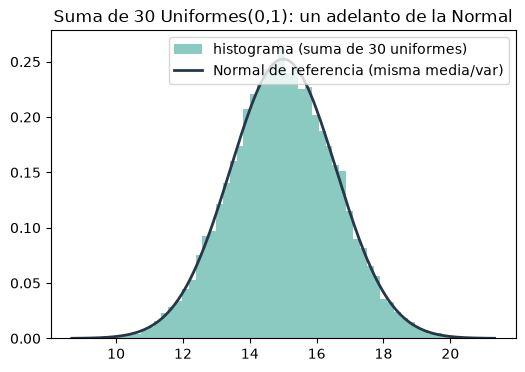

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(sumas, bins=60, density=True, color=TEAL, alpha=0.5, label="histograma (suma de 30 uniformes)")
xs = np.linspace(media_teorica - 4*np.sqrt(var_teorica), media_teorica + 4*np.sqrt(var_teorica), 300)
ax.plot(xs, stats.norm(loc=media_teorica, scale=np.sqrt(var_teorica)).pdf(xs), color=SLATE, lw=2,
        label="Normal de referencia (misma media/var)")
ax.set_title("Suma de 30 Uniformes(0,1): un adelanto de la Normal")
ax.legend()
plt.show()


## Beta (proporciones, la conjugación llega en la parte bayesiana)

Un resultado elegante: si tomo $n$ variables Uniforme(0,1) y las ordeno de menor a mayor, el $k$-ésimo valor de esa lista ordenada sigue una $\text{Beta}(k, n-k+1)$.


In [20]:
n_unif = 9
k_orden = 5
n_muestras_beta = 20000

matriz_uniformes = np.random.rand(n_muestras_beta, n_unif)
orden_k = np.sort(matriz_uniformes, axis=1)[:, k_orden - 1]

media_teorica_beta = k_orden / (n_unif + 1)
print(f"media muestral: {orden_k.mean():.4f}   media teórica (k/(n+1)): {media_teorica_beta:.4f}")

media muestral: 0.4996   media teórica (k/(n+1)): 0.5000


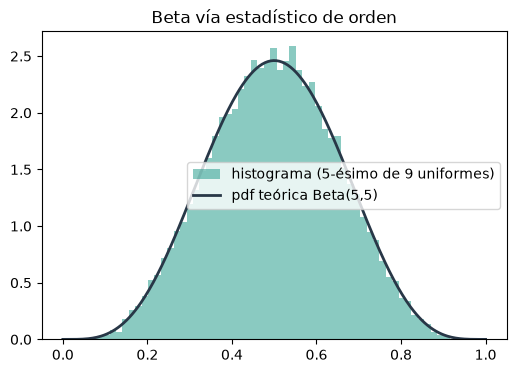

In [21]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(orden_k, bins=60, density=True, color=TEAL, alpha=0.5, label=f"histograma ({k_orden}-ésimo de {n_unif} uniformes)")
xs = np.linspace(0, 1, 300)
ax.plot(xs, stats.beta(k_orden, n_unif-k_orden+1).pdf(xs), color=SLATE, lw=2,
        label=f"pdf teórica Beta({k_orden},{n_unif-k_orden+1})")
ax.set_title("Beta vía estadístico de orden")
ax.legend()
plt.show()


## Conclusión

| Familia | De dónde sale | La volvemos a ver en... |
|---|---|---|
| Bernoulli / Binomial | conteo de éxitos en ensayos independientes | GLMs (regresión logística) |
| Poisson | conteo de eventos raros en una ventana de tiempo | GLMs (regresión Poisson) |
| Exponencial / Gamma | tiempos de espera entre eventos | modelos de supervivencia, priors |
| Normal | sumas de muchas variables independientes | prácticamente todo el semestre |
| Beta | proporciones; conjugada de Bernoulli/Binomial | Núcleo Bayesiano (conjugación) |

Ninguna de estas familias es arbitraria. Cada una es la respuesta matemática a una pregunta generativa concreta; ese es el hábito que queremos que se quede: antes de usar una distribución, preguntar de qué proceso viene.

**La próxima semana:** distribuciones conjuntas, marginales y condicionales; independencia con precisión (y el contraejemplo de que incorrelación no implica independencia); esperanza y su linealidad.
